# Iris Neural Network Tutorial

This notebook explains not just how to train a neural network on Iris, but what the network is computing at each stage.

By the end you should be able to:
- explain what one hidden neuron computes: `x @ w + b`
- track tensor shapes through the network
- explain logits, softmax probabilities, and cross-entropy loss
- inspect one backward pass and one SGD weight update
- watch selected weights, biases, gradients, and hidden activations change during training
- interpret a trained network through its decision regions and hidden representation

If your active kernel does not have the required packages yet, run `%pip install torch matplotlib pandas` in a cell before the imports.

In [1]:
import csv
from io import StringIO
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False)
pd.options.display.float_format = lambda value: f"{value:.3f}"


## Why Iris?

Iris is a good first neural-network dataset because it is small enough to inspect directly.

Each flower has only four numeric features:
1. sepal length
2. sepal width
3. petal length
4. petal width

The task is to map those four numbers to one of three species.
Because the dataset is tiny, we can stop and examine the exact tensors, weights, activations, and gradients instead of treating the model as a black box.


Dataset shape: 150 rows x 4 features


sepal length,sepal width,petal length,petal width,species
5.100000,3.500000,1.400000,0.200000,setosa
4.900000,3.000000,1.400000,0.200000,setosa
4.700000,3.200000,1.300000,0.200000,setosa
4.600000,3.100000,1.500000,0.200000,setosa
5.000000,3.600000,1.400000,0.200000,setosa
5.400000,3.900000,1.700000,0.400000,setosa
4.600000,3.400000,1.400000,0.300000,setosa
5.000000,3.400000,1.500000,0.200000,setosa


sepal length                   sepal width                    \
                   mean   std   min   max        mean   std   min   max   
species                                                                   
setosa            5.010 0.350 4.300 5.800       3.420 0.380 2.300 4.400   
versicolor        5.940 0.520 4.900 7.000       2.770 0.310 2.000 3.400   
virginica         6.590 0.640 4.900 7.900       2.970 0.320 2.200 3.800   

           petal length                   petal width                    
                   mean   std   min   max        mean   std   min   max  
species                                                                  
setosa            1.460 0.170 1.000 1.900       0.240 0.110 0.100 0.600  
versicolor        4.260 0.470 3.000 5.100       1.330 0.200 1.000 1.800  
virginica         5.550 0.550 4.500 6.900       2.030 0.270 1.400 2.500

,count
species,
setosa,50
versicolor,50
virginica,50


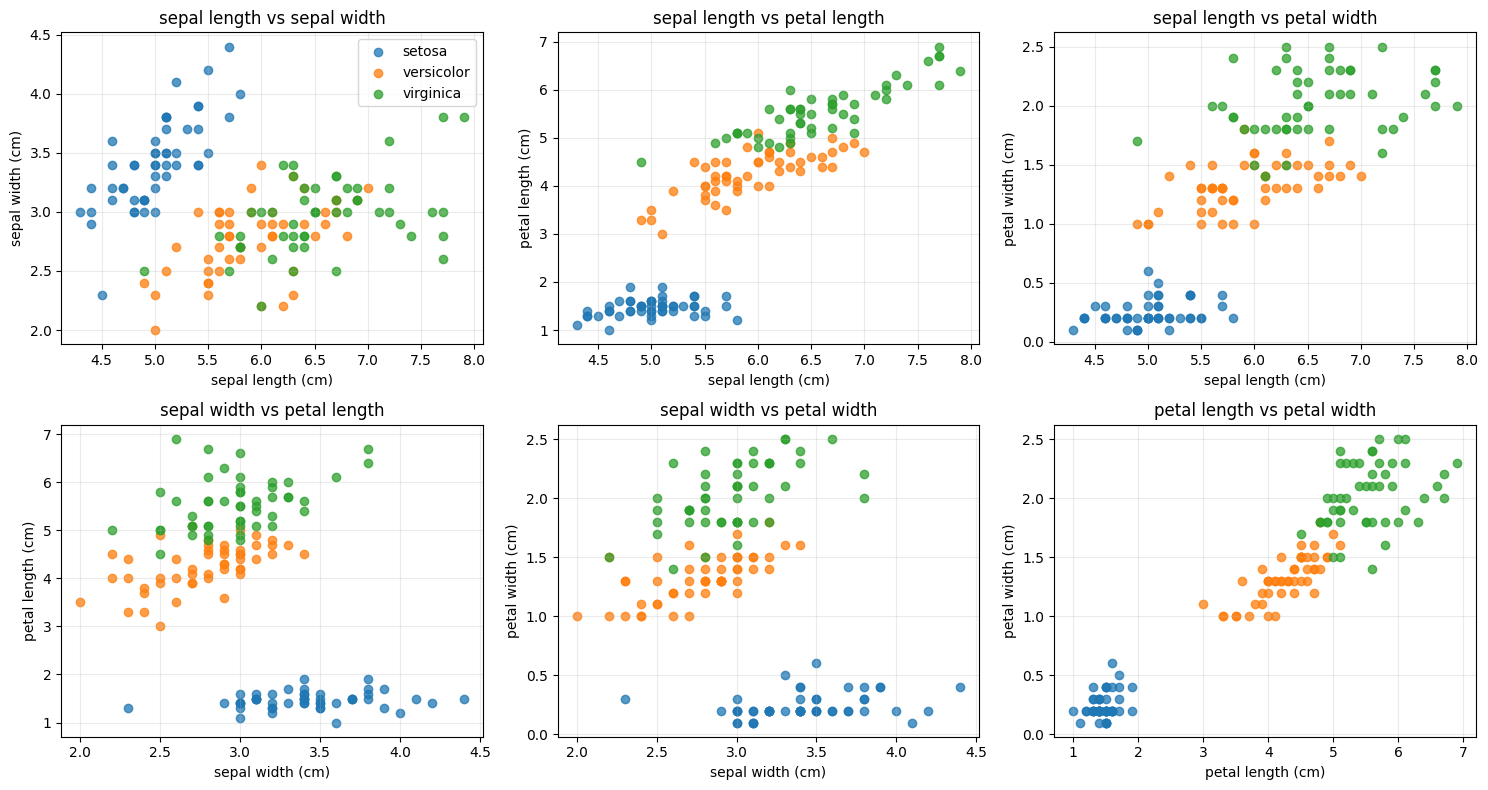

In [2]:
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
feature_names = [
    "sepal length",
    "sepal width",
    "petal length",
    "petal width",
]
class_names = ["setosa", "versicolor", "virginica"]
class_to_index = {f"Iris-{name}": index for index, name in enumerate(class_names)}
class_colors = ["tab:blue", "tab:orange", "tab:green"]

with urlopen(iris_url) as response:
    raw_csv = response.read().decode("utf-8").strip()

rows = [row for row in csv.reader(StringIO(raw_csv)) if row]
raw_features = torch.tensor(
    [[float(value) for value in row[:4]] for row in rows], dtype=torch.float32
)
labels = torch.tensor([class_to_index[row[4]] for row in rows], dtype=torch.long)

iris_df = pd.DataFrame(raw_features.numpy(), columns=feature_names)
iris_df["species"] = pd.Categorical(
    [class_names[label.item()] for label in labels],
    categories=class_names,
    ordered=True,
)

print(f"Dataset shape: {iris_df.shape[0]} rows x {len(feature_names)} features")
display(iris_df.head(8).style.hide(axis="index"))
display(
    iris_df.groupby("species",observed=True)[feature_names]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
display(
    iris_df["species"].value_counts().rename_axis("species").to_frame("count")
)

feature_pairs = [
    (x_idx, y_idx)
    for x_idx in range(len(feature_names))
    for y_idx in range(x_idx + 1, len(feature_names))
]
num_cols = 3
num_rows = (len(feature_pairs) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
axes = axes.flatten()

for ax, (x_idx, y_idx) in zip(axes, feature_pairs):
    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_idx
        ax.scatter(
            raw_features[mask, x_idx],
            raw_features[mask, y_idx],
            label=class_name,
            alpha=0.75,
            color=class_colors[class_idx],
        )
    ax.set_xlabel(f"{feature_names[x_idx]} (cm)")
    ax.set_ylabel(f"{feature_names[y_idx]} (cm)")
    ax.set_title(f"{feature_names[x_idx]} vs {feature_names[y_idx]}")
    ax.grid(alpha=0.25)

for ax in axes[len(feature_pairs):]:
    ax.set_visible(False)

axes[0].legend()
plt.tight_layout()
plt.show()


## Split And Standardize

We split the dataset before normalization and compute the mean and standard deviation on the training set only.

That matters for two reasons:
- it matches real deployment, where future test examples are unknown during training
- it avoids leaking test-set statistics into the preprocessing step

Standardization is helpful here because the four input features live on different numeric scales.


In [3]:
def stratified_split(features, labels, train_fraction=0.8, seed=42):
    generator = torch.Generator().manual_seed(seed)
    train_feature_parts = []
    train_label_parts = []
    test_feature_parts = []
    test_label_parts = []

    for class_idx in range(len(class_names)):
        class_indices = torch.nonzero(labels == class_idx, as_tuple=False).squeeze(1)
        shuffled = class_indices[
            torch.randperm(class_indices.numel(), generator=generator)
        ]
        train_count = int(train_fraction * shuffled.numel())
        train_idx = shuffled[:train_count]
        test_idx = shuffled[train_count:]
        train_feature_parts.append(features[train_idx])
        train_label_parts.append(labels[train_idx])
        test_feature_parts.append(features[test_idx])
        test_label_parts.append(labels[test_idx])

    train_features_raw = torch.cat(train_feature_parts, dim=0)
    train_labels = torch.cat(train_label_parts, dim=0)
    test_features_raw = torch.cat(test_feature_parts, dim=0)
    test_labels = torch.cat(test_label_parts, dim=0)

    train_perm = torch.randperm(train_features_raw.size(0), generator=generator)
    test_perm = torch.randperm(test_features_raw.size(0), generator=generator)
    return (
        train_features_raw[train_perm],
        train_labels[train_perm],
        test_features_raw[test_perm],
        test_labels[test_perm],
    )


(
    train_features_raw,
    train_labels,
    test_features_raw,
    test_labels,
) = stratified_split(raw_features, labels, train_fraction=0.8, seed=42)

feature_mean = train_features_raw.mean(dim=0, keepdim=True)
feature_std = train_features_raw.std(dim=0, keepdim=True)

train_features = (train_features_raw - feature_mean) / feature_std
test_features = (test_features_raw - feature_mean) / feature_std

train_dataset = TensorDataset(train_features, train_labels)
test_dataset = TensorDataset(test_features, test_labels)
train_batch_size = 16
train_loader_generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    generator=train_loader_generator,
)
test_loader = DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

# Use fixed slices for explanation cells so rerunning them does not change later shuffling.
demo_batch_features = train_features[:train_batch_size]
demo_batch_labels = train_labels[:train_batch_size]
microscope_batch_features = train_features[:8]
microscope_batch_labels = train_labels[:8]

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_features), len(test_features)],
    }
)
scale_summary = pd.DataFrame(
    {
        "feature": feature_names,
        "train_mean": feature_mean.squeeze(0).tolist(),
        "train_std": feature_std.squeeze(0).tolist(),
        "standardized_mean": train_features.mean(dim=0).tolist(),
        "standardized_std": train_features.std(dim=0).tolist(),
    }
)
class_balance = pd.DataFrame(
    {
        "train": torch.bincount(train_labels).tolist(),
        "test": torch.bincount(test_labels).tolist(),
    },
    index=class_names,
)
class_balance.index.name = "species"
deterministic_batch_summary = pd.DataFrame(
    {
        "batch_name": ["demo_batch", "microscope_batch"],
        "rows": [len(demo_batch_features), len(microscope_batch_features)],
        "purpose": [
            "shape/forward explanations",
            "fixed-batch SGD microscope",
        ],
    }
)

print("Split summary")
display(split_summary)
print("Scaling summary")
display(scale_summary.round(3))
print("Class balance after the stratified split")
display(class_balance)
print("Deterministic batches reused later in the notebook")
display(deterministic_batch_summary)

Split summary


,split,rows
0,train,120
1,test,30


Scaling summary


,feature,train_mean,train_std,standardized_mean,standardized_std
0,sepal length,5.858,0.847,0.000,1.000
1,sepal width,3.066,0.447,-0.000,1.000
2,petal length,3.768,1.776,-0.000,1.000
3,petal width,1.205,0.763,-0.000,1.000


Class balance after the stratified split


,train,test
species,,
setosa,40,10
versicolor,40,10
virginica,40,10


Deterministic batches reused later in the notebook


,batch_name,rows,purpose
0,demo_batch,16,shape/forward explanations
1,microscope_batch,8,fixed-batch SGD microscope


## The Model

We will use one hidden layer with eight neurons.

For a batch of flowers, the input tensor has shape `[batch_size, 4]` because each flower has four standardized measurements.

The first linear layer stores:
- `W1` with shape `[8, 4]`
- `b1` with shape `[8]`

PyTorch computes:
- `x @ W1^T` so `[batch_size, 4] @ [4, 8] -> [batch_size, 8]`
- then adds `b1`, broadcasting `[8]` across the batch, so the result stays `[batch_size, 8]`
- then applies `ReLU`, keeping the same shape `[batch_size, 8]`

So the hidden activations are:

`hidden = ReLU(x @ W1^T + b1)`

The output layer stores:
- `W2` with shape `[3, 8]`
- `b2` with shape `[3]`

It computes:
- `hidden @ W2^T` so `[batch_size, 8] @ [8, 3] -> [batch_size, 3]`
- then adds `b2`, broadcasting `[3]` across the batch

So the final logits are:

`logits = hidden @ W2^T + b2`

That `[batch_size, 3]` output contains one unnormalized score per flower for each iris species.


In [4]:
class IrisNet(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=8, num_classes=3):
        super().__init__()
        # fc1 maps 4 input features to 8 hidden neurons.
        # weight shape: [8, 4], bias shape: [8]
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # fc2 maps 8 hidden activations to 3 class logits.
        # weight shape: [3, 8], bias shape: [3]
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward_features(self, x):
        # x shape: [batch_size, 4]
        # hidden_pre = x @ fc1.weight.T + fc1.bias
        #            = [batch_size, 4] @ [4, 8] + [8]
        #            = [batch_size, 8]
        hidden_pre = self.fc1(x)

        # ReLU keeps the same shape and replaces negative values with 0.
        # hidden shape: [batch_size, 8]
        hidden = F.relu(hidden_pre)

        # logits = hidden @ fc2.weight.T + fc2.bias
        #        = [batch_size, 8] @ [8, 3] + [3]
        #        = [batch_size, 3]
        logits = self.fc2(hidden)

        return logits, {
            "hidden_pre": hidden_pre,
            "hidden": hidden,
            "logits": logits,
        }

    def forward(self, x):
        logits, _ = self.forward_features(x)
        return logits


def count_parameters(module):
    return sum(
        parameter.numel() for parameter in module.parameters() if parameter.requires_grad
    )


demo_model = IrisNet()
batch_features = demo_batch_features
batch_labels = demo_batch_labels
batch_size = batch_features.shape[0]
example_x = batch_features[0]
example_y = batch_labels[0].item()

with torch.no_grad():
    batch_logits, batch_activations = demo_model.forward_features(batch_features)
    example_logits, example_activations = demo_model.forward_features(
        example_x.unsqueeze(0)
    )
    example_probabilities = torch.softmax(example_logits, dim=1)

first_hidden_weights = demo_model.fc1.weight[0].detach()
first_hidden_bias = demo_model.fc1.bias[0].detach()
first_hidden_products = example_x * first_hidden_weights
manual_hidden_pre = first_hidden_products.sum() + first_hidden_bias

first_output_weights = demo_model.fc2.weight[0].detach()
first_output_bias = demo_model.fc2.bias[0].detach()
first_output_products = example_activations["hidden"][0] * first_output_weights
manual_logit0 = first_output_products.sum() + first_output_bias

print(demo_model)
print()
print("Forward pass shapes")
print("-" * 64)
print(f"input x shape:          {tuple(batch_features.shape)} = [batch_size, input_dim]")
print(
    f"fc1 weight shape:       {tuple(demo_model.fc1.weight.shape)} = [hidden_dim, input_dim]"
)
print(f"fc1 bias shape:         {tuple(demo_model.fc1.bias.shape)} = [hidden_dim]")
print(
    f"fc1 weight.T shape:     {tuple(demo_model.fc1.weight.T.shape)} = [input_dim, hidden_dim]"
)
print(
    f"hidden_pre shape:       {tuple(batch_activations['hidden_pre'].shape)} = [batch_size, hidden_dim]"
)
print(
    f"hidden after ReLU:      {tuple(batch_activations['hidden'].shape)} = [batch_size, hidden_dim]"
)
print(
    f"fc2 weight shape:       {tuple(demo_model.fc2.weight.shape)} = [num_classes, hidden_dim]"
)
print(f"fc2 bias shape:         {tuple(demo_model.fc2.bias.shape)} = [num_classes]")
print(
    f"fc2 weight.T shape:     {tuple(demo_model.fc2.weight.T.shape)} = [hidden_dim, num_classes]"
)
print(f"output logits shape:    {tuple(batch_logits.shape)} = [batch_size, num_classes]")
print("-" * 64)
print()
print("Exact calculations for this batch")
print("-" * 64)
print(
    f"hidden_pre = x @ W1.T + b1 -> ({batch_size}, 4) @ (4, 8) + (8,) = {tuple(batch_activations['hidden_pre'].shape)}"
)
print(
    f"hidden     = ReLU(hidden_pre) -> {tuple(batch_activations['hidden_pre'].shape)} -> {tuple(batch_activations['hidden'].shape)}"
)
print(
    f"logits     = hidden @ W2.T + b2 -> ({batch_size}, 8) @ (8, 3) + (3,) = {tuple(batch_logits.shape)}"
)
print("-" * 64)
print()
print("Meaning of each dimension")
print("-" * 64)
print("batch_size = number of flowers processed together")
print("input_dim = 4 sepal/petal measurements per flower")
print("hidden_dim = 8 learned hidden neurons")
print("num_classes = 3 iris species logits")
print("-" * 64)
print()
print("Example values for the first flower in this batch")
print("-" * 64)
print("True class:", class_names[example_y])
print("x[0] (the 4 standardized input features):")
print(example_x)
print()
print("First hidden neuron using actual numbers")
print("weights for hidden neuron 0:")
print(first_hidden_weights)
print("elementwise products x[0] * W1[0]:")
print(first_hidden_products)
print("sum(products) + bias:", f"{manual_hidden_pre.item():.4f}")
print(
    "fc1 output for hidden neuron 0:",
    f"{example_activations['hidden_pre'][0, 0].item():.4f}",
)
print()
print("All 8 hidden pre-activations for this flower:")
print(example_activations["hidden_pre"].squeeze(0))
print("All 8 hidden activations after ReLU:")
print(example_activations["hidden"].squeeze(0))
print()
print("First output logit using actual numbers")
print("weights for class-0 logit:")
print(first_output_weights)
print("elementwise products hidden * W2[0]:")
print(first_output_products)
print("sum(products) + bias:", f"{manual_logit0.item():.4f}")
print("fc2 output logit for class 0:", f"{example_logits[0, 0].item():.4f}")
print()
print("All 3 logits for this flower:")
print(example_logits.squeeze(0))
print("Softmax probabilities:")
print(example_probabilities.squeeze(0))
print("-" * 64)
print()
print(
    "fc1 parameters: 8 * (4 + 1) =",
    demo_model.fc1.weight.numel() + demo_model.fc1.bias.numel(),
)
print(
    "fc2 parameters: 3 * (8 + 1) =",
    demo_model.fc2.weight.numel() + demo_model.fc2.bias.numel(),
)
print("Total trainable parameters:", count_parameters(demo_model))

IrisNet(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)

Forward pass shapes
----------------------------------------------------------------
input x shape:          (16, 4) = [batch_size, input_dim]
fc1 weight shape:       (8, 4) = [hidden_dim, input_dim]
fc1 bias shape:         (8,) = [hidden_dim]
fc1 weight.T shape:     (4, 8) = [input_dim, hidden_dim]
hidden_pre shape:       (16, 8) = [batch_size, hidden_dim]
hidden after ReLU:      (16, 8) = [batch_size, hidden_dim]
fc2 weight shape:       (3, 8) = [num_classes, hidden_dim]
fc2 bias shape:         (3,) = [num_classes]
fc2 weight.T shape:     (8, 3) = [hidden_dim, num_classes]
output logits shape:    (16, 3) = [batch_size, num_classes]
----------------------------------------------------------------

Exact calculations for this batch
----------------------------------------------------------------
hidden_pre = x @ W1.T + b1 -> (16, 4) @ (4, 8) + (8,) = (16, 8)
h

## One Flower Through The Network

A full batch can hide what is happening. The next cell follows one flower through the untrained network and manually recomputes two values:
- the first hidden neuron's pre-activation
- the first output logit

The values are random because the model is still untrained, but the mechanics are exactly the same after training.


Standardized input flower:
tensor([-0.069, -0.818,  0.750,  0.911])
True class: virginica

First hidden neuron
weights:
tensor([ 0.382,  0.415, -0.117,  0.459])
elementwise products:
tensor([-0.026, -0.339, -0.088,  0.418])
Manual weighted sum + bias: 0.3510
Model value from fc1: 0.3510
After ReLU: 0.3510

All hidden pre-activations:
tensor([ 0.351,  0.093,  0.518,  0.345, -0.068,  0.618, -0.109,  0.194])
All hidden activations after ReLU:
tensor([0.351, 0.093, 0.518, 0.345, 0.000, 0.618, 0.000, 0.194])

Manual logit for class 0: 0.2355
Model logit for class 0: 0.2355
Logits:
tensor([ 0.235, -0.052,  0.216])
Softmax probabilities:
tensor([0.366, 0.275, 0.359])
Probability sum: 1.0000


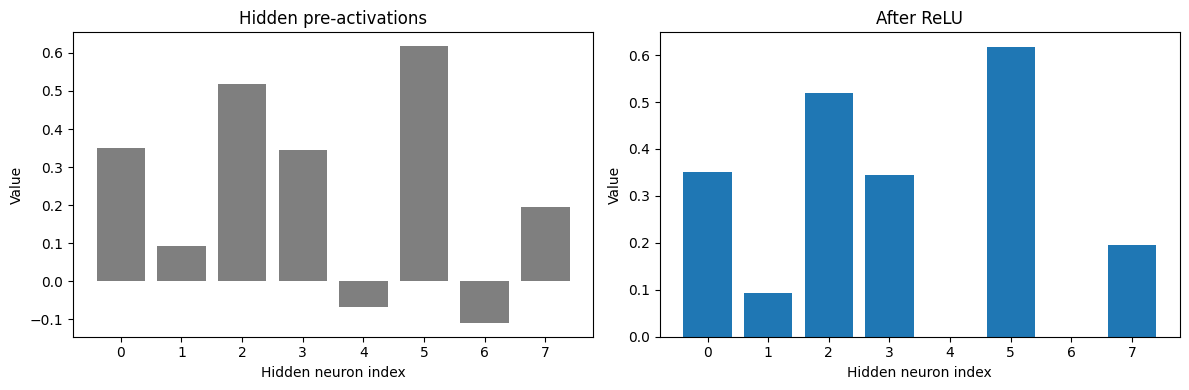

In [5]:
example_features, example_label_tensor = train_dataset[0]
example_label = example_label_tensor.item()

with torch.no_grad():
    single_logits, single_activations = demo_model.forward_features(example_features.unsqueeze(0))
    single_probabilities = torch.softmax(single_logits, dim=1)

first_hidden_weights = demo_model.fc1.weight[0].detach()
first_hidden_bias = demo_model.fc1.bias[0].detach()
hidden_products = example_features * first_hidden_weights
manual_hidden_pre = hidden_products.sum() + first_hidden_bias
manual_hidden_post = manual_hidden_pre.clamp_min(0.0)

first_output_weights = demo_model.fc2.weight[0].detach()
first_output_bias = demo_model.fc2.bias[0].detach()
manual_logit0 = (single_activations["hidden"][0] * first_output_weights).sum() + first_output_bias

print("Standardized input flower:")
print(example_features)
print("True class:", class_names[example_label])
print()
print("First hidden neuron")
print("weights:")
print(first_hidden_weights)
print("elementwise products:")
print(hidden_products)
print("Manual weighted sum + bias:", f"{manual_hidden_pre.item():.4f}")
print("Model value from fc1:", f"{single_activations['hidden_pre'][0, 0].item():.4f}")
print("After ReLU:", f"{manual_hidden_post.item():.4f}")
print()
print("All hidden pre-activations:")
print(single_activations["hidden_pre"].squeeze(0))
print("All hidden activations after ReLU:")
print(single_activations["hidden"].squeeze(0))
print()
print("Manual logit for class 0:", f"{manual_logit0.item():.4f}")
print("Model logit for class 0:", f"{single_logits[0, 0].item():.4f}")
print("Logits:")
print(single_logits.squeeze(0))
print("Softmax probabilities:")
print(single_probabilities.squeeze(0))
print("Probability sum:", f"{single_probabilities.sum().item():.4f}")

hidden_indices = torch.arange(single_activations["hidden"].shape[1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(hidden_indices, single_activations["hidden_pre"].squeeze(0).tolist(), color="tab:gray")
axes[0].set_title("Hidden pre-activations")
axes[0].set_xlabel("Hidden neuron index")
axes[0].set_ylabel("Value")

axes[1].bar(hidden_indices, single_activations["hidden"].squeeze(0).tolist(), color="tab:blue")
axes[1].set_title("After ReLU")
axes[1].set_xlabel("Hidden neuron index")
axes[1].set_ylabel("Value")
plt.tight_layout()
plt.show()


## Loss, Backprop, And One Update

`CrossEntropyLoss` expects logits and integer class labels.
For one example, the loss is the negative log-probability assigned to the true class.

After the forward pass computes the loss, `loss.backward()` uses the chain rule to populate gradients for every trainable parameter.
`optimizer.step()` then moves each weight in the direction that reduces the loss.


In [6]:
single_label = example_label_tensor.unsqueeze(0)
single_loss = F.cross_entropy(single_logits, single_label)
manual_loss = -torch.log(single_probabilities[0, example_label])

print("Cross-entropy on one example:", f"{single_loss.item():.4f}")
print("Manual -log(p_true):", f"{manual_loss.item():.4f}")
print("True-class probability:", f"{single_probabilities[0, example_label].item():.4f}")


def inspect_training_step(model, batch_features, batch_labels, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer.zero_grad()

    logits, activations = model.forward_features(batch_features)
    loss = F.cross_entropy(logits, batch_labels)
    loss.backward()

    tracked_before = {
        "fc1.weight[0,0]": model.fc1.weight[0, 0].item(),
        "fc1.bias[0]": model.fc1.bias[0].item(),
        "fc2.weight[0,0]": model.fc2.weight[0, 0].item(),
        "fc2.bias[0]": model.fc2.bias[0].item(),
    }
    tracked_grad = {
        "fc1.weight[0,0]": model.fc1.weight.grad[0, 0].item(),
        "fc1.bias[0]": model.fc1.bias.grad[0].item(),
        "fc2.weight[0,0]": model.fc2.weight.grad[0, 0].item(),
        "fc2.bias[0]": model.fc2.bias.grad[0].item(),
    }
    expected_after = {
        name: tracked_before[name] - lr * tracked_grad[name]
        for name in tracked_before
    }
    fc1_grad_norm = model.fc1.weight.grad.norm().item()
    fc2_grad_norm = model.fc2.weight.grad.norm().item()
    relu_active_fraction = activations["hidden"].gt(0).float().mean().item()
    first_probs = torch.softmax(logits[0].detach(), dim=0)
    first_pred = logits.argmax(dim=1)[0].item()

    optimizer.step()
    tracked_after = {
        "fc1.weight[0,0]": model.fc1.weight[0, 0].item(),
        "fc1.bias[0]": model.fc1.bias[0].item(),
        "fc2.weight[0,0]": model.fc2.weight[0, 0].item(),
        "fc2.bias[0]": model.fc2.bias[0].item(),
    }

    print("Batch shape:", tuple(batch_features.shape))
    print("Hidden activation shape:", tuple(activations["hidden"].shape))
    print("Logits shape:", tuple(logits.shape))
    print("Loss before update:", f"{loss.item():.4f}")
    print("First sample true class:", class_names[batch_labels[0].item()])
    print("First sample predicted class:", class_names[first_pred])
    print("First sample probabilities:")
    print(first_probs)
    print("Gradient norm for fc1 weights:", f"{fc1_grad_norm:.4f}")
    print("Gradient norm for fc2 weights:", f"{fc2_grad_norm:.4f}")
    print("ReLU active fraction in this batch:", f"{relu_active_fraction:.3f}")

    update_table = pd.DataFrame(
        {
            "before": tracked_before,
            "gradient": tracked_grad,
            "expected_after": expected_after,
            "actual_after": tracked_after,
        }
    )
    print("Tracked weight and bias updates")
    display(update_table.round(6))


step_model = IrisNet()
mini_batch_features = microscope_batch_features
mini_batch_labels = microscope_batch_labels
inspect_training_step(step_model, mini_batch_features, mini_batch_labels, lr=0.1)

Cross-entropy on one example: 1.0242
Manual -log(p_true): 1.0242
True-class probability: 0.3591


Batch shape: (8, 4)
Hidden activation shape: (8, 8)
Logits shape: (8, 3)
Loss before update: 1.3552
First sample true class: virginica
First sample predicted class: virginica
First sample probabilities:
tensor([0.361, 0.204, 0.435])
Gradient norm for fc1 weights: 0.5292
Gradient norm for fc2 weights: 0.8308
ReLU active fraction in this batch: 0.344
Tracked weight and bias updates


,before,gradient,expected_after,actual_after
"fc1.weight[0,0]",-0.296,0.000,-0.296,-0.296
fc1.bias[0],-0.484,0.000,-0.484,-0.484
"fc2.weight[0,0]",-0.195,0.000,-0.195,-0.195
fc2.bias[0],0.110,-0.337,0.144,0.144


## Train The Network

Now we repeat that same forward and backward process for many batches.
The notebook uses plain SGD so the earlier `old_weight - lr * gradient` explanation matches the optimizer that actually trains the model.

This time we also keep an epoch-level training observatory. For every epoch we record:
- train and test loss
- train and test accuracy
- parameter norms for both layers
- gradient norms for both layers
- selected weights and biases
- hidden-activation summaries on the full training set

The gradient norms below come from the **final batch of each epoch**. They answer “how sensitive was the loss on that last update step?” rather than “what is the exact full-dataset gradient?”

Epoch   1: train loss 1.0213, train acc 0.358, test loss 0.9243, test acc 0.900
  final-batch grad norms fc1=0.2023, fc2=0.4259; ReLU active fraction=0.552
  tracked params fc1.weight[0,0]=-0.1194, fc1.bias[0]=-0.2454, fc2.weight[0,0]=-0.0624, fc2.bias[0]=0.1063
Epoch  25: train loss 0.1583, train acc 0.950, test loss 0.1361, test acc 0.933
  final-batch grad norms fc1=0.0993, fc2=0.0829; ReLU active fraction=0.560
  tracked params fc1.weight[0,0]=-0.3861, fc1.bias[0]=0.0200, fc2.weight[0,0]=0.8410, fc2.bias[0]=0.0902
Epoch  50: train loss 0.0805, train acc 0.975, test loss 0.0815, test acc 0.967
  final-batch grad norms fc1=0.2615, fc2=0.2430; ReLU active fraction=0.570
  tracked params fc1.weight[0,0]=-0.4572, fc1.bias[0]=0.0737, fc2.weight[0,0]=0.9957, fc2.bias[0]=0.0561


Epoch  75: train loss 0.0597, train acc 0.975, test loss 0.0767, test acc 0.967
  final-batch grad norms fc1=0.4806, fc2=0.4811; ReLU active fraction=0.566
  tracked params fc1.weight[0,0]=-0.4991, fc1.bias[0]=0.1046, fc2.weight[0,0]=1.0778, fc2.bias[0]=0.0410


Epoch 100: train loss 0.0507, train acc 0.983, test loss 0.0678, test acc 0.967
  final-batch grad norms fc1=0.2118, fc2=0.0570; ReLU active fraction=0.568
  tracked params fc1.weight[0,0]=-0.5277, fc1.bias[0]=0.1253, fc2.weight[0,0]=1.1321, fc2.bias[0]=0.0321
Epoch 125: train loss 0.0439, train acc 0.983, test loss 0.0669, test acc 0.967
  final-batch grad norms fc1=0.3547, fc2=0.2981; ReLU active fraction=0.562
  tracked params fc1.weight[0,0]=-0.5491, fc1.bias[0]=0.1401, fc2.weight[0,0]=1.1724, fc2.bias[0]=0.0253
Epoch 150: train loss 0.0424, train acc 0.983, test loss 0.0834, test acc 0.967
  final-batch grad norms fc1=0.4449, fc2=0.3861; ReLU active fraction=0.556
  tracked params fc1.weight[0,0]=-0.5661, fc1.bias[0]=0.1518, fc2.weight[0,0]=1.2036, fc2.bias[0]=0.0201
Selected epochs from the training observatory


,epoch,train_loss,train_accuracy,test_loss,test_accuracy,fc1_grad_norm,fc2_grad_norm,relu_active_fraction,"fc1.weight[0,0]",fc1.bias[0],"fc2.weight[0,0]",fc2.bias[0]
0,1,1.021,0.358,0.924,0.900,0.202,0.426,0.552,-0.119,-0.245,-0.062,0.106
24,25,0.158,0.950,0.136,0.933,0.099,0.083,0.560,-0.386,0.020,0.841,0.090
49,50,0.081,0.975,0.082,0.967,0.262,0.243,0.570,-0.457,0.074,0.996,0.056
74,75,0.060,0.975,0.077,0.967,0.481,0.481,0.566,-0.499,0.105,1.078,0.041
99,100,0.051,0.983,0.068,0.967,0.212,0.057,0.568,-0.528,0.125,1.132,0.032
124,125,0.044,0.983,0.067,0.967,0.355,0.298,0.562,-0.549,0.140,1.172,0.025
149,150,0.042,0.983,0.083,0.967,0.445,0.386,0.556,-0.566,0.152,1.204,0.020


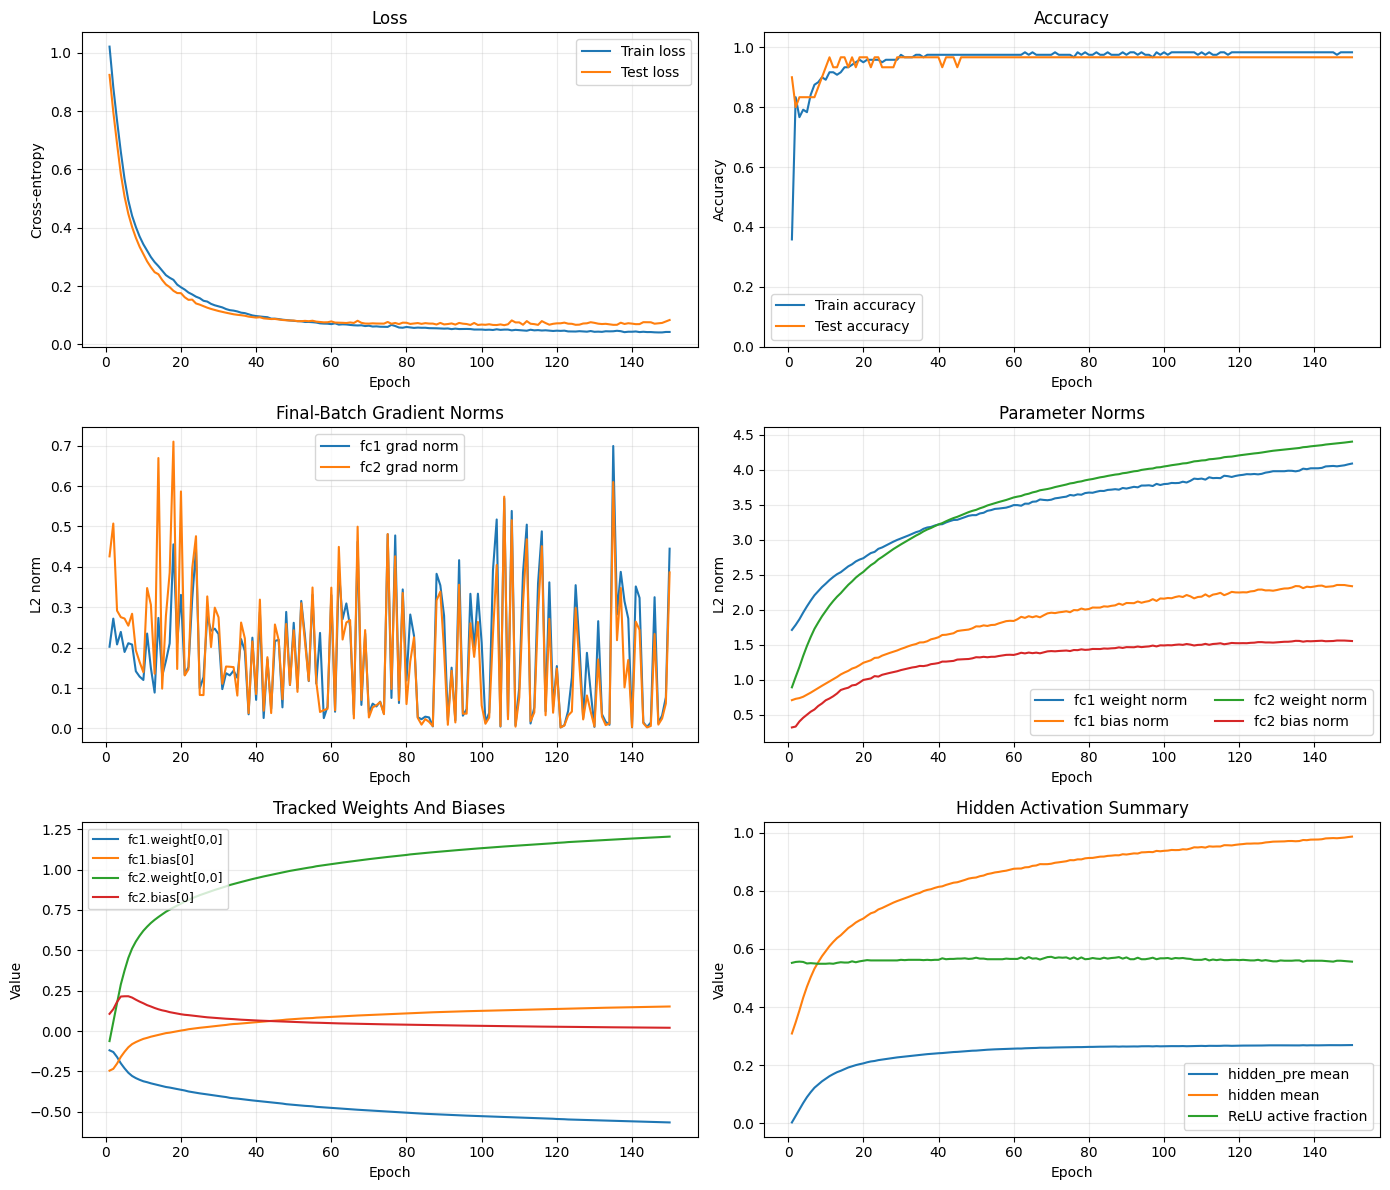

How to read the observatory
- Large gradient norms mean the loss on the final batch of that epoch was sensitive to that layer.
- Flattening parameter curves usually mean SGD updates are getting smaller and more stable.
- The ReLU active fraction shows how often hidden units are switched on across the training set.
- Because the tracked parameters are real weights and biases, you can connect the curves directly to the SGD rule.


In [7]:
tracked_parameter_specs = {
    "fc1.weight[0,0]": ("fc1.weight", (0, 0)),
    "fc1.bias[0]": ("fc1.bias", (0,)),
    "fc2.weight[0,0]": ("fc2.weight", (0, 0)),
    "fc2.bias[0]": ("fc2.bias", (0,)),
}


def get_named_tensor(module, tensor_name):
    module_name, attribute_name = tensor_name.rsplit(".", 1)
    owner = dict(module.named_modules())[module_name]
    return getattr(owner, attribute_name)


def tracked_parameter_values(module):
    values = {}
    for display_name, (tensor_name, index) in tracked_parameter_specs.items():
        values[display_name] = get_named_tensor(module, tensor_name)[index].detach().item()
    return values


def tracked_gradient_values(module):
    values = {}
    for display_name, (tensor_name, index) in tracked_parameter_specs.items():
        tensor = get_named_tensor(module, tensor_name)
        grad = tensor.grad
        values[display_name] = float("nan") if grad is None else grad[index].detach().item()
    return values


def parameter_norms(module):
    return {
        "fc1_weight_norm": module.fc1.weight.detach().norm().item(),
        "fc1_bias_norm": module.fc1.bias.detach().norm().item(),
        "fc2_weight_norm": module.fc2.weight.detach().norm().item(),
        "fc2_bias_norm": module.fc2.bias.detach().norm().item(),
    }


def gradient_norms(module):
    return {
        "fc1_grad_norm": 0.0 if module.fc1.weight.grad is None else module.fc1.weight.grad.detach().norm().item(),
        "fc2_grad_norm": 0.0 if module.fc2.weight.grad is None else module.fc2.weight.grad.detach().norm().item(),
    }


def activation_summary(activations):
    hidden_pre = activations["hidden_pre"].detach()
    hidden = activations["hidden"].detach()
    return {
        "hidden_pre_mean": hidden_pre.mean().item(),
        "hidden_mean": hidden.mean().item(),
        "relu_active_fraction": hidden.gt(0).float().mean().item(),
    }


def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    seen = 0

    with torch.no_grad():
        for batch_features, batch_labels in loader:
            logits = model(batch_features)
            total_loss += F.cross_entropy(logits, batch_labels, reduction="sum").item()
            predictions = logits.argmax(dim=1)
            correct += predictions.eq(batch_labels).sum().item()
            seen += batch_labels.size(0)

    return total_loss / seen, correct / seen


def fit(model, train_loader, test_loader, train_features, train_labels, epochs=150, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history_rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        seen = 0

        for batch_features, batch_labels in train_loader:
            optimizer.zero_grad()
            logits, _ = model.forward_features(batch_features)
            loss = F.cross_entropy(logits, batch_labels)
            loss.backward()
            optimizer.step()

            batch_size = batch_labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += logits.argmax(dim=1).eq(batch_labels).sum().item()
            seen += batch_size

        train_loss = running_loss / seen
        train_accuracy = running_correct / seen
        test_loss, test_accuracy = evaluate_model(model, test_loader)

        with torch.no_grad():
            _, full_train_activations = model.forward_features(train_features)

        snapshot = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        }
        snapshot.update(parameter_norms(model))
        snapshot.update(gradient_norms(model))
        snapshot.update(activation_summary(full_train_activations))
        snapshot.update(tracked_parameter_values(model))
        history_rows.append(snapshot)

        if epoch == 1 or epoch % 25 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:>3}: "
                f"train loss {train_loss:.4f}, train acc {train_accuracy:.3f}, "
                f"test loss {test_loss:.4f}, test acc {test_accuracy:.3f}"
            )
            print(
                "  final-batch grad norms "
                f"fc1={snapshot['fc1_grad_norm']:.4f}, fc2={snapshot['fc2_grad_norm']:.4f}; "
                f"ReLU active fraction={snapshot['relu_active_fraction']:.3f}"
            )
            print(
                "  tracked params "
                f"fc1.weight[0,0]={snapshot['fc1.weight[0,0]']:.4f}, "
                f"fc1.bias[0]={snapshot['fc1.bias[0]']:.4f}, "
                f"fc2.weight[0,0]={snapshot['fc2.weight[0,0]']:.4f}, "
                f"fc2.bias[0]={snapshot['fc2.bias[0]']:.4f}"
            )

    return pd.DataFrame(history_rows)


trained_model = IrisNet()
history_df = fit(
    trained_model,
    train_loader,
    test_loader,
    train_features,
    train_labels,
    epochs=150,
    lr=0.1,
)

selected_epoch_mask = history_df["epoch"].isin([1, 25, 50, 75, 100, 125, 150])
summary_columns = [
    "epoch",
    "train_loss",
    "train_accuracy",
    "test_loss",
    "test_accuracy",
    "fc1_grad_norm",
    "fc2_grad_norm",
    "relu_active_fraction",
    "fc1.weight[0,0]",
    "fc1.bias[0]",
    "fc2.weight[0,0]",
    "fc2.bias[0]",
]
print("Selected epochs from the training observatory")
display(history_df.loc[selected_epoch_mask, summary_columns].round(4))

epoch_axis = history_df["epoch"]
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

axes[0].plot(epoch_axis, history_df["train_loss"], label="Train loss")
axes[0].plot(epoch_axis, history_df["test_loss"], label="Test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epoch_axis, history_df["train_accuracy"], label="Train accuracy")
axes[1].plot(epoch_axis, history_df["test_accuracy"], label="Test accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.05)
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(epoch_axis, history_df["fc1_grad_norm"], label="fc1 grad norm")
axes[2].plot(epoch_axis, history_df["fc2_grad_norm"], label="fc2 grad norm")
axes[2].set_title("Final-Batch Gradient Norms")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("L2 norm")
axes[2].grid(alpha=0.25)
axes[2].legend()

axes[3].plot(epoch_axis, history_df["fc1_weight_norm"], label="fc1 weight norm")
axes[3].plot(epoch_axis, history_df["fc1_bias_norm"], label="fc1 bias norm")
axes[3].plot(epoch_axis, history_df["fc2_weight_norm"], label="fc2 weight norm")
axes[3].plot(epoch_axis, history_df["fc2_bias_norm"], label="fc2 bias norm")
axes[3].set_title("Parameter Norms")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("L2 norm")
axes[3].grid(alpha=0.25)
axes[3].legend(ncol=2)

for tracked_name in tracked_parameter_specs:
    axes[4].plot(epoch_axis, history_df[tracked_name], label=tracked_name)
axes[4].set_title("Tracked Weights And Biases")
axes[4].set_xlabel("Epoch")
axes[4].set_ylabel("Value")
axes[4].grid(alpha=0.25)
axes[4].legend(fontsize=9)

axes[5].plot(epoch_axis, history_df["hidden_pre_mean"], label="hidden_pre mean")
axes[5].plot(epoch_axis, history_df["hidden_mean"], label="hidden mean")
axes[5].plot(epoch_axis, history_df["relu_active_fraction"], label="ReLU active fraction")
axes[5].set_title("Hidden Activation Summary")
axes[5].set_xlabel("Epoch")
axes[5].set_ylabel("Value")
axes[5].grid(alpha=0.25)
axes[5].legend()

plt.tight_layout()
plt.show()

print("How to read the observatory")
print("- Large gradient norms mean the loss on the final batch of that epoch was sensitive to that layer.")
print("- Flattening parameter curves usually mean SGD updates are getting smaller and more stable.")
print("- The ReLU active fraction shows how often hidden units are switched on across the training set.")
print("- Because the tracked parameters are real weights and biases, you can connect the curves directly to the SGD rule.")

## SGD Microscope

The epoch plots show the long-term trend. The next cell slows training down and fixes **one mini-batch** in place.

That means only one thing changes from step to step: the model parameters.
This makes it easy to inspect an exact sequence of updates:
- the same input batch is reused each time
- the loss and probabilities change only because the weights and biases changed
- for each tracked parameter you can compare `before`, `gradient`, `expected_after`, and `actual_after`

The microscope starts from a **fresh model** rather than the trained one above. That keeps the gradients large enough to inspect clearly.

Fixed-batch SGD microscope overview


,step,loss,true_class,predicted_class,p_true,hidden_pre_mean,hidden_mean,relu_active_fraction
0,1,1.119,virginica,setosa,0.359,-0.032,0.225,0.578
1,2,1.077,virginica,setosa,0.350,-0.029,0.225,0.594
2,3,1.034,virginica,setosa,0.342,-0.022,0.229,0.594
3,4,0.994,virginica,setosa,0.336,-0.015,0.233,0.594
4,5,0.954,virginica,setosa,0.330,-0.007,0.239,0.609


Exact tracked parameter updates across the same five SGD steps


,step,"fc1.weight[0,0] before","fc1.weight[0,0] grad","fc1.weight[0,0] expected_after","fc1.weight[0,0] after",fc1.bias[0] before,fc1.bias[0] grad,fc1.bias[0] expected_after,fc1.bias[0] after,"fc2.weight[0,0] before","fc2.weight[0,0] grad","fc2.weight[0,0] expected_after","fc2.weight[0,0] after",fc2.bias[0] before,fc2.bias[0] grad,fc2.bias[0] expected_after,fc2.bias[0] after
0,1,0.382,-0.005,0.383,0.383,0.386,-0.004,0.386,0.386,0.095,0.004,0.095,0.095,0.108,-0.277,0.136,0.136
1,2,0.383,-0.006,0.383,0.383,0.386,-0.006,0.387,0.387,0.095,0.010,0.094,0.094,0.136,-0.257,0.162,0.162
2,3,0.383,-0.006,0.384,0.384,0.387,-0.007,0.388,0.388,0.094,0.015,0.092,0.092,0.162,-0.237,0.185,0.185
3,4,0.384,-0.006,0.385,0.385,0.388,-0.008,0.389,0.389,0.092,0.021,0.090,0.090,0.185,-0.217,0.207,0.207
4,5,0.385,-0.006,0.385,0.385,0.389,-0.009,0.390,0.390,0.090,0.026,0.087,0.087,0.207,-0.197,0.227,0.227


Predicted probabilities for one tracked flower across the same five updates


,step,setosa,versicolor,virginica
0,1,0.366,0.275,0.359
1,2,0.374,0.276,0.350
2,3,0.380,0.278,0.342
3,4,0.385,0.279,0.336
4,5,0.389,0.281,0.330


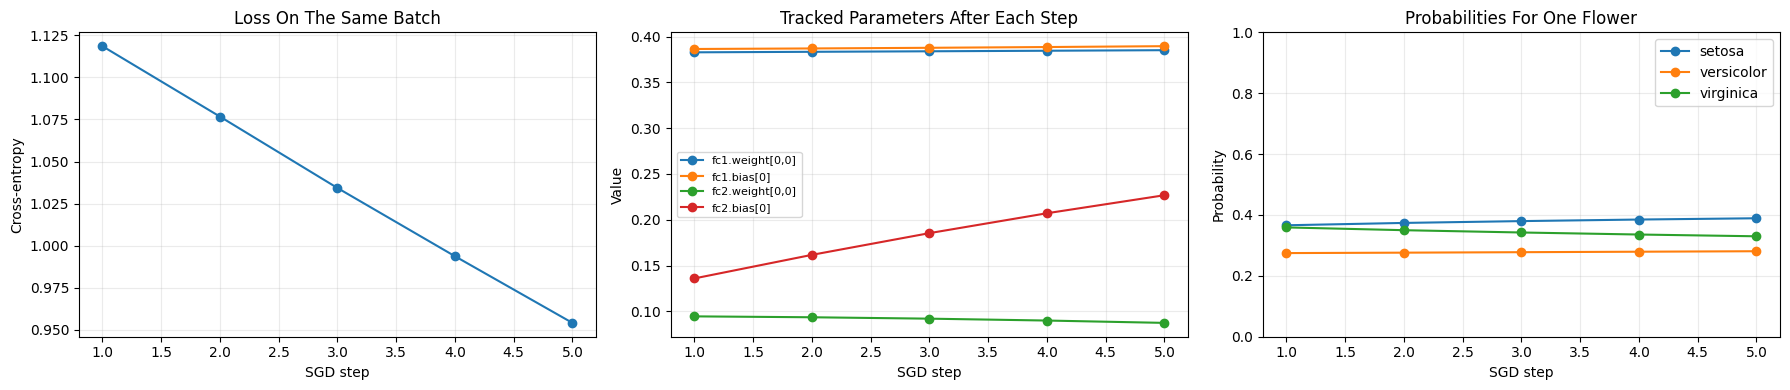

How to read one microscope row
- If a gradient is positive, SGD subtracts it and the parameter moves down.
- If a gradient is negative, SGD subtracts a negative number and the parameter moves up.
- Matching expected_after and actual_after confirms the update really is old - lr * grad.


In [8]:
def run_sgd_microscope(
    model,
    batch_features,
    batch_labels,
    lr=0.1,
    steps=5,
    tracked_example_index=0,
):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    rows = []
    probability_rows = []
    tracked_example_label = batch_labels[tracked_example_index].item()

    for step in range(1, steps + 1):
        optimizer.zero_grad()
        logits, activations = model.forward_features(batch_features)
        loss = F.cross_entropy(logits, batch_labels)
        probabilities = torch.softmax(logits.detach(), dim=1)
        before = tracked_parameter_values(model)
        loss.backward()
        grads = tracked_gradient_values(model)
        expected_after = {
            name: before[name] - lr * grads[name]
            for name in tracked_parameter_specs
        }
        optimizer.step()
        after = tracked_parameter_values(model)

        row = {
            "step": step,
            "loss": loss.item(),
            "true_class": class_names[tracked_example_label],
            "predicted_class": class_names[probabilities[tracked_example_index].argmax().item()],
            "p_true": probabilities[tracked_example_index, tracked_example_label].item(),
        }
        row.update(activation_summary(activations))
        for name in tracked_parameter_specs:
            row[f"{name} before"] = before[name]
            row[f"{name} grad"] = grads[name]
            row[f"{name} expected_after"] = expected_after[name]
            row[f"{name} after"] = after[name]
        rows.append(row)
        probability_rows.append(
            {
                "step": step,
                **{
                    class_name: probabilities[tracked_example_index, class_index].item()
                    for class_index, class_name in enumerate(class_names)
                },
            }
        )

    return pd.DataFrame(rows), pd.DataFrame(probability_rows)


torch.manual_seed(42)
microscope_model = IrisNet()
microscope_history_df, microscope_probabilities_df = run_sgd_microscope(
    microscope_model,
    microscope_batch_features,
    microscope_batch_labels,
    lr=0.1,
    steps=5,
)

overview_columns = [
    "step",
    "loss",
    "true_class",
    "predicted_class",
    "p_true",
    "hidden_pre_mean",
    "hidden_mean",
    "relu_active_fraction",
]
parameter_columns = ["step"]
for tracked_name in tracked_parameter_specs:
    parameter_columns.extend(
        [
            f"{tracked_name} before",
            f"{tracked_name} grad",
            f"{tracked_name} expected_after",
            f"{tracked_name} after",
        ]
    )

print("Fixed-batch SGD microscope overview")
display(microscope_history_df[overview_columns].round(4))
print("Exact tracked parameter updates across the same five SGD steps")
display(microscope_history_df[parameter_columns].round(6))
print("Predicted probabilities for one tracked flower across the same five updates")
display(microscope_probabilities_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(microscope_history_df["step"], microscope_history_df["loss"], marker="o")
axes[0].set_title("Loss On The Same Batch")
axes[0].set_xlabel("SGD step")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(alpha=0.25)

for tracked_name in tracked_parameter_specs:
    axes[1].plot(
        microscope_history_df["step"],
        microscope_history_df[f"{tracked_name} after"],
        marker="o",
        label=tracked_name,
    )
axes[1].set_title("Tracked Parameters After Each Step")
axes[1].set_xlabel("SGD step")
axes[1].set_ylabel("Value")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

for class_name in class_names:
    axes[2].plot(
        microscope_probabilities_df["step"],
        microscope_probabilities_df[class_name],
        marker="o",
        label=class_name,
    )
axes[2].set_title("Probabilities For One Flower")
axes[2].set_xlabel("SGD step")
axes[2].set_ylabel("Probability")
axes[2].set_ylim(0.0, 1.0)
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()

print("How to read one microscope row")
print("- If a gradient is positive, SGD subtracts it and the parameter moves down.")
print("- If a gradient is negative, SGD subtracts a negative number and the parameter moves up.")
print("- Matching expected_after and actual_after confirms the update really is old - lr * grad.")

## Evaluate And Interpret The Trained Network

After the observatory and the fixed-batch microscope, we can connect the math back to behavior.

The next cells answer four questions:
- how often is the model correct?
- which classes still get mixed up?
- what probabilities does the model assign to one test flower?
- how does the learned hidden representation reorganize the data?

Test accuracy: 0.967


predicted,setosa,versicolor,virginica
true,,,
setosa,10,0,0
versicolor,0,9,1
virginica,0,0,10


Misclassified test examples


,test_index,true,predicted
0,2,versicolor,virginica


Predicted probabilities for one test flower


,species,probability
0,virginica,0.891
1,versicolor,0.109
2,setosa,0.000


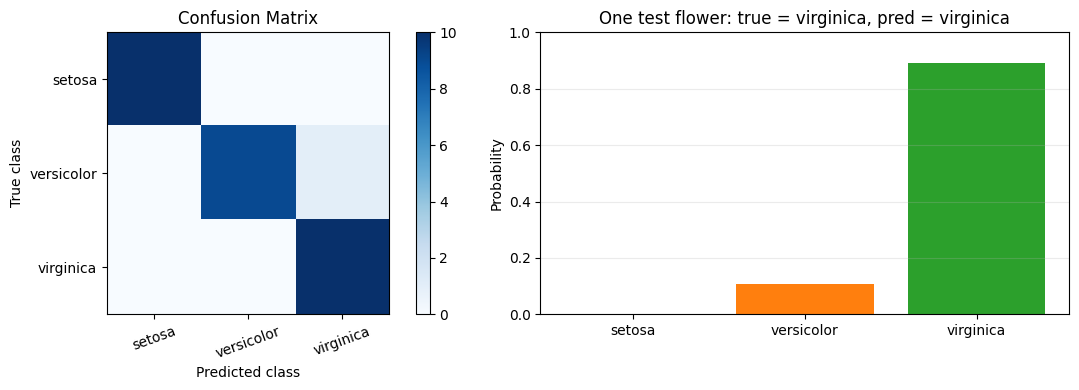

In [9]:
def build_confusion_matrix(targets, predictions, num_classes):
    confusion = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for target, prediction in zip(targets, predictions):
        confusion[target, prediction] += 1
    return confusion


trained_model.eval()
with torch.no_grad():
    train_logits, train_activations = trained_model.forward_features(train_features)
    test_logits, test_activations = trained_model.forward_features(test_features)
    test_probabilities = torch.softmax(test_logits, dim=1)
    test_predictions = test_probabilities.argmax(dim=1)

test_accuracy = test_predictions.eq(test_labels).float().mean().item()
confusion = build_confusion_matrix(test_labels, test_predictions, len(class_names))
confusion_df = pd.DataFrame(confusion.numpy(), index=class_names, columns=class_names)
confusion_df.index.name = "true"
confusion_df.columns.name = "predicted"

print(f"Test accuracy: {test_accuracy:.3f}")
display(confusion_df)

wrong_indices = torch.nonzero(test_predictions != test_labels, as_tuple=False).squeeze(1)
if wrong_indices.numel() == 0:
    print("No misclassifications in this split.")
else:
    misclassified_df = pd.DataFrame(
        {
            "test_index": wrong_indices.tolist(),
            "true": [class_names[test_labels[index].item()] for index in wrong_indices],
            "predicted": [class_names[test_predictions[index].item()] for index in wrong_indices],
        }
    )
    print("Misclassified test examples")
    display(misclassified_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

image = axes[0].imshow(confusion.numpy(), cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")
axes[0].set_xticks(range(len(class_names)), class_names, rotation=20)
axes[0].set_yticks(range(len(class_names)), class_names)
plt.colorbar(image, ax=axes[0])

sample_index = 0
sample_probs = test_probabilities[sample_index]
sample_true = class_names[test_labels[sample_index].item()]
sample_pred = class_names[test_predictions[sample_index].item()]
sample_prob_df = pd.DataFrame(
    {
        "species": class_names,
        "probability": sample_probs.tolist(),
    }
).sort_values("probability", ascending=False, ignore_index=True)
print("Predicted probabilities for one test flower")
display(sample_prob_df.round(3))
axes[1].bar(class_names, sample_probs.tolist(), color=class_colors)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Probability")
axes[1].set_title(f"One test flower: true = {sample_true}, pred = {sample_pred}")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

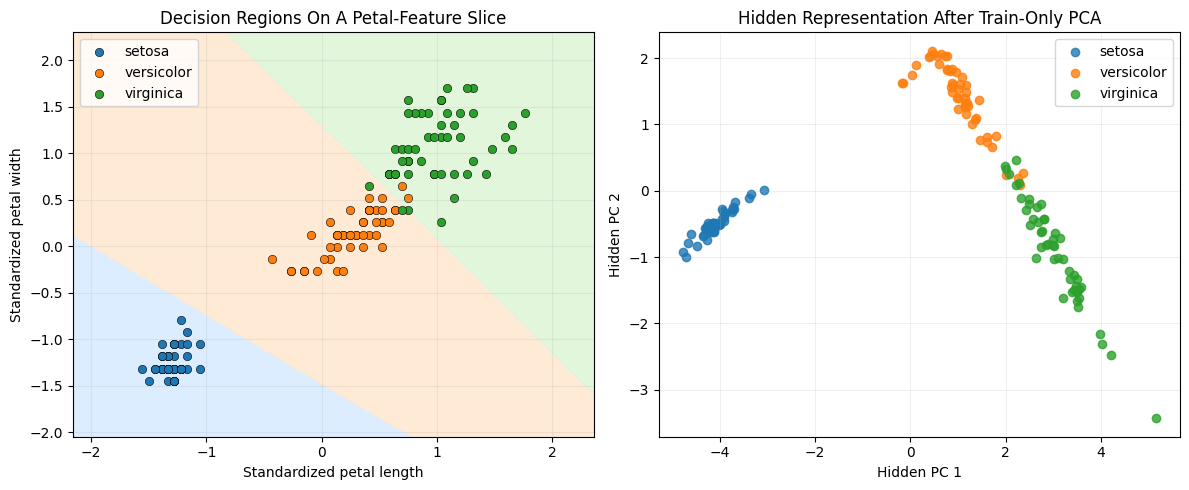

In [10]:
combined_features = torch.cat([train_features, test_features], dim=0)
combined_labels = torch.cat([train_labels, test_labels], dim=0)
petal_features = combined_features[:, 2:4]

x_min = petal_features[:, 0].min().item() - 0.6
x_max = petal_features[:, 0].max().item() + 0.6
y_min = petal_features[:, 1].min().item() - 0.6
y_max = petal_features[:, 1].max().item() + 0.6

grid_x, grid_y = torch.meshgrid(
    torch.linspace(x_min, x_max, 220),
    torch.linspace(y_min, y_max, 220),
    indexing="xy",
)
grid_inputs = torch.zeros(grid_x.numel(), 4)
grid_inputs[:, 2] = grid_x.reshape(-1)
grid_inputs[:, 3] = grid_y.reshape(-1)

with torch.no_grad():
    grid_predictions = trained_model(grid_inputs).argmax(dim=1).reshape(grid_x.shape)

background_cmap = ListedColormap(["#d9ecff", "#ffe8d1", "#def5d8"])

train_hidden_mean = train_activations["hidden"].mean(dim=0, keepdim=True)
train_hidden_centered = train_activations["hidden"] - train_hidden_mean
_, _, principal_directions = torch.pca_lowrank(train_hidden_centered, q=2)
train_hidden_2d = train_hidden_centered @ principal_directions[:, :2]
test_hidden_centered = test_activations["hidden"] - train_hidden_mean
test_hidden_2d = test_hidden_centered @ principal_directions[:, :2]
hidden_2d = torch.cat([train_hidden_2d, test_hidden_2d], dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contourf(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_predictions.numpy(),
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=background_cmap,
    alpha=0.9,
)
for class_idx, class_name in enumerate(class_names):
    mask = combined_labels == class_idx
    axes[0].scatter(
        petal_features[mask, 0],
        petal_features[mask, 1],
        color=class_colors[class_idx],
        label=class_name,
        edgecolor="black",
        linewidth=0.4,
    )
axes[0].set_title("Decision Regions On A Petal-Feature Slice")
axes[0].set_xlabel("Standardized petal length")
axes[0].set_ylabel("Standardized petal width")
axes[0].legend()
axes[0].grid(alpha=0.2)

for class_idx, class_name in enumerate(class_names):
    mask = combined_labels == class_idx
    axes[1].scatter(
        hidden_2d[mask, 0],
        hidden_2d[mask, 1],
        color=class_colors[class_idx],
        label=class_name,
        alpha=0.8,
    )
axes[1].set_title("Hidden Representation After Train-Only PCA")
axes[1].set_xlabel("Hidden PC 1")
axes[1].set_ylabel("Hidden PC 2")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

## Takeaways

- A hidden neuron is just a weighted sum plus a bias, followed by a nonlinearity.
- ReLU keeps positive evidence and blocks negative responses.
- The final layer returns logits, not probabilities. Softmax converts logits into probabilities that sum to `1`.
- Cross-entropy gets smaller when the model assigns higher probability to the true class.
- Backpropagation fills in gradients for every parameter, and SGD applies `new_weight = old_weight - learning_rate * gradient`.
- The training observatory lets you watch parameter norms, gradient norms, selected weights and biases, and hidden activations change across epochs.
- The fixed-batch SGD microscope confirms numerically that the update really is `old - learning_rate * gradient` for both weights and biases.
- The hidden layer learns a representation where the species become easier to separate.